# 📦 Train-Test Split

> **Folder:** `01_Data_Preprocessing / Train_Test_Split`  
> **Notebook:** `train_test_split.ipynb`  
> **Author:** Hamna Munir

---

## 🎯 Objectives

By the end of this notebook, you will:

- Understand **why** train-test splitting is the foundation of every ML workflow
- Apply **8 splitting strategies** with real examples and visualizations
- Understand and **prevent data leakage** in preprocessing pipelines
- Know **which strategy to choose** based on your data type and size
- Use **sklearn Pipelines** to guarantee leak-free preprocessing in every fold

---

## 📚 Techniques Covered

| # | Strategy | Best For |
|---|----------|----------|
| 1 | Simple Random Split | Large, balanced, independent data |
| 2 | Stratified Split | Imbalanced classification |
| 3 | Three-Way Holdout | Full model dev workflow |
| 4 | K-Fold CV | Small–medium datasets |
| 5 | Stratified K-Fold | Imbalanced + CV |
| 6 | Time Series Split | Sequential / temporal data |
| 7 | Group K-Fold | Grouped data (patients, users) |
| 8 | Leakage-Free Pipeline | Production-ready preprocessing |

---
## ⚙️ 0. Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    KFold,
    StratifiedKFold,
    LeaveOneOut,
    TimeSeriesSplit,
    GroupKFold,
    cross_val_score,
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted')

print('✅ Libraries loaded successfully!')

✅ Libraries loaded successfully!


---
## 📊 1. Create Dataset

In [2]:
# ── Synthetic Imbalanced Dataset ─────────────────────────────────────────
np.random.seed(42)
n = 1000

X = pd.DataFrame({
    'Age'    : np.random.randint(20, 65, n),
    'Salary' : np.random.randint(30_000, 150_000, n),
    'Score'  : np.random.uniform(0, 100, n),
    'Income' : np.random.exponential(50_000, n),
})

# Imbalanced target: 80% class 0, 20% class 1
y = pd.Series(
    np.random.choice([0, 1], size=n, p=[0.80, 0.20]),
    name='Target'
)

# Group labels for GroupKFold demo
groups = pd.Series(np.random.randint(0, 100, n), name='PatientID')

print(f'Dataset Shape : {X.shape}')
print(f'Class Balance : {dict(y.value_counts().sort_index())}')
print(f'Imbalance Ratio: {y.value_counts()[0]/y.value_counts()[1]:.1f}:1')
X.head()

Dataset Shape : (1000, 4)
Class Balance : {0: 806, 1: 194}
Imbalance Ratio: 4.2:1


,Age,Salary,Score,Income
0,58,53930,88.2533,29934.1681
1,48,30077,8.2509,32025.0180
2,34,135881,82.4514,48711.8443
3,62,50611,35.7801,31719.7462
4,27,46984,32.2095,29662.2092


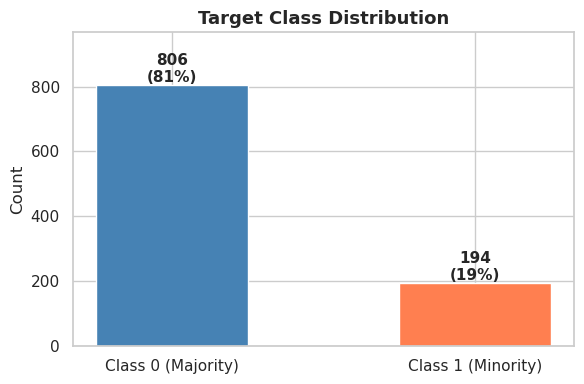

In [3]:
# ── Visualize Class Imbalance ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))
counts = y.value_counts().sort_index()
bars = ax.bar(['Class 0 (Majority)', 'Class 1 (Minority)'],
               counts.values,
               color=['steelblue', 'coral'], edgecolor='white', width=0.5)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8,
            f'{val}\n({val/n*100:.0f}%)', ha='center', fontsize=11, fontweight='bold')
ax.set_title('Target Class Distribution', fontsize=13, fontweight='bold')
ax.set_ylabel('Count')
ax.set_ylim(0, max(counts.values) * 1.2)
plt.tight_layout()
plt.show()

---
## 1️⃣ Simple Random Split

> Randomly shuffles and divides data into train and test sets.
>
> ⚠️ Does **not** preserve class distribution — problematic for imbalanced data.

In [4]:
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X, y, test_size=0.2, shuffle=True, random_state=42
)

print(f'Train: {X_train_r.shape} | Test: {X_test_r.shape}')
print(f'Train class dist : {dict(y_train_r.value_counts().sort_index())}')
print(f'Test  class dist : {dict(y_test_r.value_counts().sort_index())}')

Train: (800, 4) | Test: (200, 4)
Train class dist : {0: 637, 1: 163}
Test  class dist : {0: 169, 1: 31}


---
## 2️⃣ Stratified Split

> Uses `stratify=y` to preserve class distribution in both train and test sets.
>
> ✅ The **recommended default** for all classification tasks.

Train: (800, 4) | Test: (200, 4)
Train class dist : {0: 645, 1: 155}
Test  class dist : {0: 161, 1: 39}


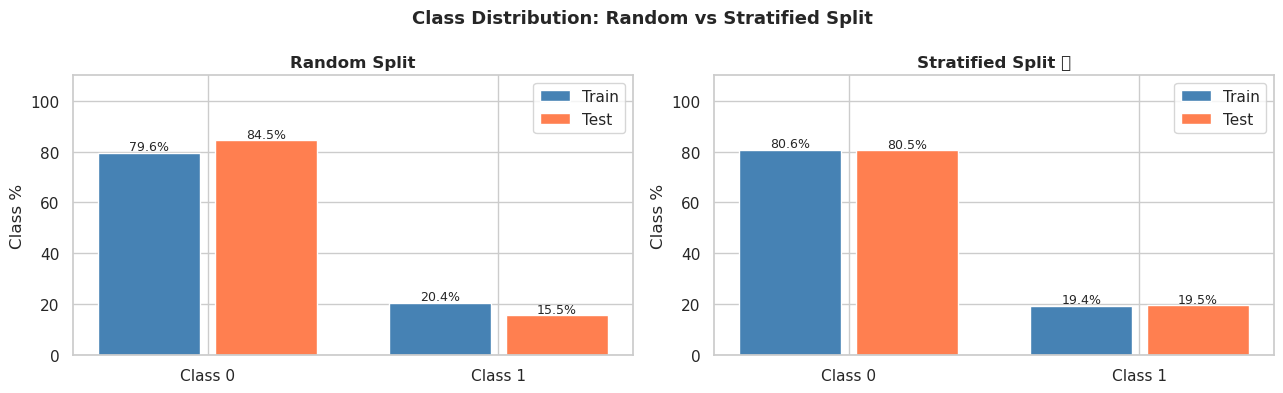

In [5]:
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f'Train: {X_train_s.shape} | Test: {X_test_s.shape}')
print(f'Train class dist : {dict(y_train_s.value_counts().sort_index())}')
print(f'Test  class dist : {dict(y_test_s.value_counts().sort_index())}')

# ── Side-by-side comparison: Random vs Stratified ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, y_tr, y_te, title in [
    (axes[0], y_train_r, y_test_r, 'Random Split'),
    (axes[1], y_train_s, y_test_s, 'Stratified Split ✅'),
]:
    x_pos = np.arange(2)
    train_pcts = y_tr.value_counts(normalize=True).sort_index().values * 100
    test_pcts  = y_te.value_counts(normalize=True).sort_index().values * 100

    ax.bar(x_pos - 0.2, train_pcts, 0.35, label='Train', color='steelblue', edgecolor='white')
    ax.bar(x_pos + 0.2, test_pcts,  0.35, label='Test',  color='coral',     edgecolor='white')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(['Class 0', 'Class 1'])
    ax.set_ylabel('Class %')
    ax.set_ylim(0, 110)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend()
    for i, (tr, te) in enumerate(zip(train_pcts, test_pcts)):
        ax.text(i - 0.2, tr + 1, f'{tr:.1f}%', ha='center', fontsize=9)
        ax.text(i + 0.2, te + 1, f'{te:.1f}%', ha='center', fontsize=9)

plt.suptitle('Class Distribution: Random vs Stratified Split', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 3️⃣ Three-Way Holdout Split

> Divides data into **Train / Validation / Test** sets.
>
> ✅ Proper workflow for hyperparameter tuning + final evaluation.

Train:  800 rows (80.0%) | Class dist: {0: 644, 1: 156}
Val  :  100 rows (10.0%) | Class dist: {0: 81, 1: 19}
Test :  100 rows (10.0%) | Class dist: {0: 81, 1: 19}


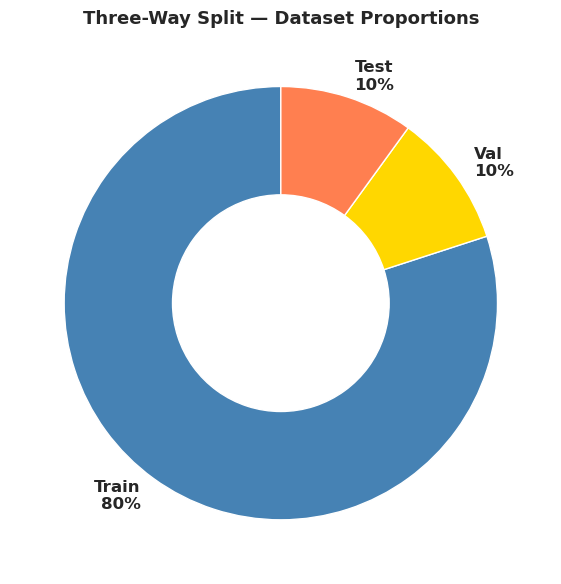

In [6]:
# Step 1: Hold out 10% as the locked test set
X_temp, X_test_3, y_temp, y_test_3 = train_test_split(
    X, y, test_size=0.10, stratify=y, random_state=42
)
# Step 2: Split remaining 90% into 80% train / 10% val
X_train_3, X_val_3, y_train_3, y_val_3 = train_test_split(
    X_temp, y_temp, test_size=0.111, stratify=y_temp, random_state=42
)

for name, X_s, y_s in [
    ('Train', X_train_3, y_train_3),
    ('Val',   X_val_3,   y_val_3),
    ('Test',  X_test_3,  y_test_3),
]:
    pct = len(X_s) / len(X) * 100
    print(f'{name:5s}: {len(X_s):4d} rows ({pct:.1f}%) | '
          f'Class dist: {dict(y_s.value_counts().sort_index())}')

# ── Donut chart ───────────────────────────────────────────────────────────
sizes  = [len(X_train_3), len(X_val_3), len(X_test_3)]
labels = [f'Train\n{len(X_train_3)/len(X)*100:.0f}%',
          f'Val\n{len(X_val_3)/len(X)*100:.0f}%',
          f'Test\n{len(X_test_3)/len(X)*100:.0f}%']
colors = ['steelblue', 'gold', 'coral']

fig, ax = plt.subplots(figsize=(6, 6))
wedges, texts = ax.pie(sizes, labels=labels, colors=colors,
                        startangle=90, wedgeprops=dict(width=0.5),
                        textprops=dict(fontsize=12, fontweight='bold'))
ax.set_title('Three-Way Split — Dataset Proportions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 4️⃣ K-Fold Cross-Validation

> Trains on K-1 folds, validates on 1 fold — rotates K times. Uses **all data**.
>
> ✅ More reliable performance estimate than a single holdout split.

In [7]:
model = RandomForestClassifier(n_estimators=50, random_state=42)
kf    = KFold(n_splits=5, shuffle=True, random_state=42)

kf_scores = cross_val_score(model, X, y, cv=kf, scoring='accuracy')

print('K-Fold CV Results (K=5):')
for i, s in enumerate(kf_scores, 1):
    print(f'  Fold {i}: {s:.4f}')
print(f'\n  Mean : {kf_scores.mean():.4f}')
print(f'  Std  : {kf_scores.std():.4f}')

K-Fold CV Results (K=5):
  Fold 1: 0.8350
  Fold 2: 0.7350
  Fold 3: 0.8200
  Fold 4: 0.7900
  Fold 5: 0.7900

  Mean : 0.7940
  Std  : 0.0343


---
## 5️⃣ Stratified K-Fold

> K-Fold with class balance preserved in **every single fold**.
>
> ✅ The **recommended default** for classification cross-validation.

In [8]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Inspect class balance per fold
fold_info = []
for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    y_val_fold = y.iloc[val_idx]
    cls_counts = y_val_fold.value_counts().sort_index()
    fold_info.append({
        'Fold'         : fold,
        'Val Size'     : len(val_idx),
        'Class 0 %'    : round(cls_counts.get(0, 0) / len(val_idx) * 100, 1),
        'Class 1 %'    : round(cls_counts.get(1, 0) / len(val_idx) * 100, 1),
    })

skf_scores = cross_val_score(model, X, y, cv=skf, scoring='accuracy')

fold_df = pd.DataFrame(fold_info)
fold_df['Accuracy'] = [round(s, 4) for s in skf_scores]
print('Stratified K-Fold — Per-Fold Details:')
print(fold_df.to_string(index=False))
print(f'\nMean Accuracy : {skf_scores.mean():.4f} ± {skf_scores.std():.4f}')

Stratified K-Fold — Per-Fold Details:
 Fold  Val Size  Class 0 %  Class 1 %  Accuracy
    1       200    81.0000    19.0000    0.7850
    2       200    80.5000    19.5000    0.7950
    3       200    80.5000    19.5000    0.7950
    4       200    80.5000    19.5000    0.8000
    5       200    80.5000    19.5000    0.8000

Mean Accuracy : 0.7950 ± 0.0055


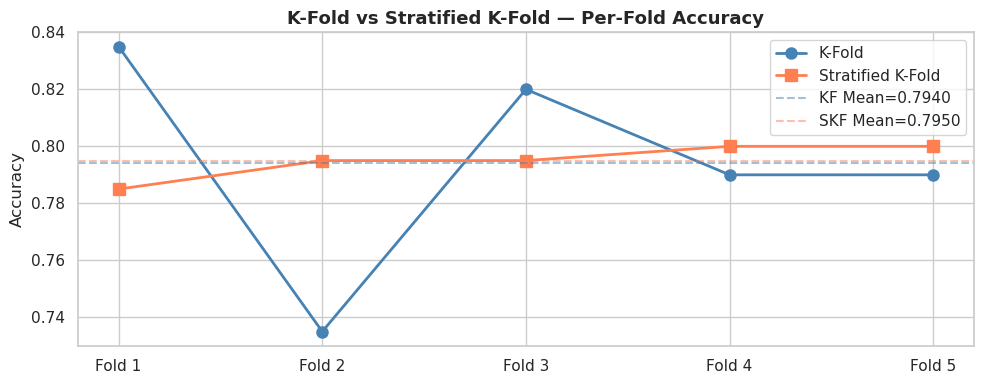

In [9]:
# ── K-Fold vs Stratified K-Fold Score Comparison ─────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))

x_pos = np.arange(1, 6)
ax.plot(x_pos, kf_scores,  'o-', color='steelblue', lw=2, ms=8, label='K-Fold')
ax.plot(x_pos, skf_scores, 's-', color='coral',     lw=2, ms=8, label='Stratified K-Fold')

ax.axhline(kf_scores.mean(),  color='steelblue', linestyle='--', alpha=0.5,
           label=f'KF Mean={kf_scores.mean():.4f}')
ax.axhline(skf_scores.mean(), color='coral',     linestyle='--', alpha=0.5,
           label=f'SKF Mean={skf_scores.mean():.4f}')

ax.set_xticks(x_pos)
ax.set_xticklabels([f'Fold {i}' for i in x_pos])
ax.set_ylabel('Accuracy')
ax.set_title('K-Fold vs Stratified K-Fold — Per-Fold Accuracy', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

---
## 6️⃣ Time Series Split (Walk-Forward Validation)

> Test always comes **after** train in time — no future data leaks into training.
>
> ❌ Never shuffle time-ordered data!

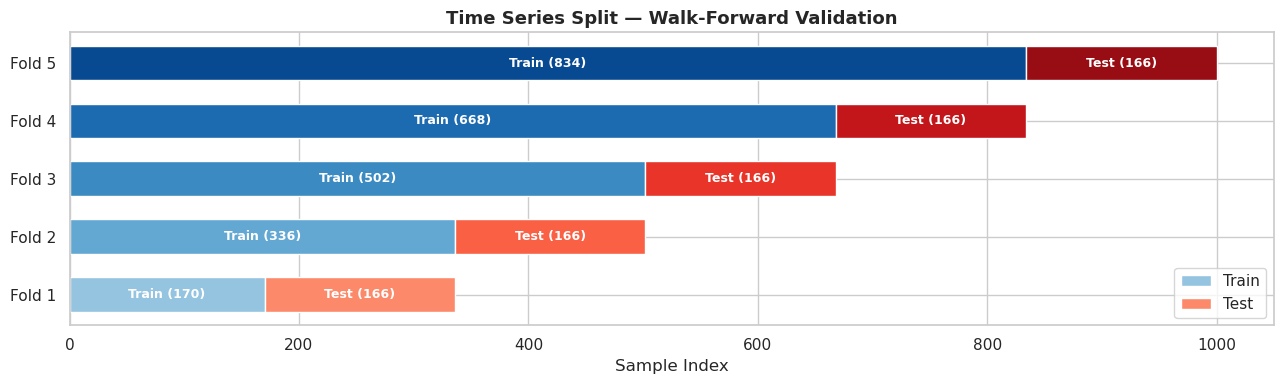

TimeSeriesSplit Accuracy: 0.7843 ± 0.0469


In [10]:
tscv = TimeSeriesSplit(n_splits=5)

# ── Visualize fold boundaries ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 4))

colors_train = plt.cm.Blues(np.linspace(0.4, 0.9, 5))
colors_test  = plt.cm.Reds(np.linspace(0.4, 0.9, 5))

for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    ax.barh(fold, len(train_idx), left=0,
            color=colors_train[fold], edgecolor='white', height=0.6,
            label='Train' if fold == 0 else '')
    ax.barh(fold, len(test_idx), left=len(train_idx),
            color=colors_test[fold], edgecolor='white', height=0.6,
            label='Test' if fold == 0 else '')
    ax.text(len(train_idx)/2, fold, f'Train ({len(train_idx)})',
            va='center', ha='center', fontsize=9, color='white', fontweight='bold')
    ax.text(len(train_idx) + len(test_idx)/2, fold, f'Test ({len(test_idx)})',
            va='center', ha='center', fontsize=9, color='white', fontweight='bold')

ax.set_yticks(range(5))
ax.set_yticklabels([f'Fold {i+1}' for i in range(5)])
ax.set_xlabel('Sample Index')
ax.set_title('Time Series Split — Walk-Forward Validation', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

ts_scores = cross_val_score(model, X, y, cv=tscv, scoring='accuracy')
print(f'TimeSeriesSplit Accuracy: {ts_scores.mean():.4f} ± {ts_scores.std():.4f}')

---
## 7️⃣ Group K-Fold

> Samples from the **same group never appear** in both train and test.
>
> ✅ Essential for patient data, user sessions, or any grouped dataset.

In [11]:
gkf = GroupKFold(n_splits=5)

fold_details = []
for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups), 1):
    train_groups = set(groups.iloc[train_idx].unique())
    test_groups  = set(groups.iloc[test_idx].unique())
    overlap = train_groups & test_groups
    fold_details.append({
        'Fold'           : fold,
        'Train Rows'     : len(train_idx),
        'Test Rows'      : len(test_idx),
        'Train Groups'   : len(train_groups),
        'Test Groups'    : len(test_groups),
        'Group Overlap'  : len(overlap),
    })

gkf_df = pd.DataFrame(fold_details)
print('Group K-Fold — Fold Details:')
print(gkf_df.to_string(index=False))
print('\n✅ Group Overlap = 0 in all folds — no leakage!')

gkf_scores = cross_val_score(model, X, y, groups=groups, cv=gkf, scoring='accuracy')
print(f'\nGroup K-Fold Accuracy: {gkf_scores.mean():.4f} ± {gkf_scores.std():.4f}')

Group K-Fold — Fold Details:
 Fold  Train Rows  Test Rows  Train Groups  Test Groups  Group Overlap
    1         801        199            80           20              0
    2         799        201            80           20              0
    3         799        201            80           20              0
    4         799        201            80           20              0
    5         802        198            80           20              0

✅ Group Overlap = 0 in all folds — no leakage!

Group K-Fold Accuracy: 0.7911 ± 0.0200


---
## ⚠️ 8. Data Leakage — The Silent Model Killer

❌ Leaky  (scaler fit on full data) : Accuracy = 0.7400
✅ Correct (scaler fit on train only): Accuracy = 0.8000
   Difference: 0.0600 — leakage inflates score!


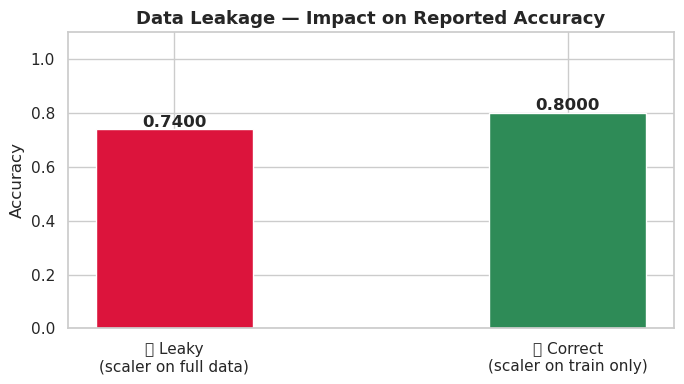

In [12]:
# ── WRONG: Fit scaler on full data (leaks test info into train) ───────────
scaler_leaky = StandardScaler()
X_leaked = scaler_leaky.fit_transform(X)          # ❌ sees test data!
X_tr_l   = X_leaked[:800]
X_te_l   = X_leaked[800:]
y_tr_l, y_te_l = y[:800], y[800:]

model_l = RandomForestClassifier(n_estimators=50, random_state=42)
model_l.fit(X_tr_l, y_tr_l)
acc_leaky = accuracy_score(y_te_l, model_l.predict(X_te_l))

# ── CORRECT: Fit scaler on train only (no leakage) ────────────────────────
X_tr_c, X_te_c, y_tr_c, y_te_c = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
scaler_clean = StandardScaler()
X_tr_scaled  = scaler_clean.fit_transform(X_tr_c)  # ✅ train only!
X_te_scaled  = scaler_clean.transform(X_te_c)

model_c = RandomForestClassifier(n_estimators=50, random_state=42)
model_c.fit(X_tr_scaled, y_tr_c)
acc_clean = accuracy_score(y_te_c, model_c.predict(X_te_scaled))

print(f'❌ Leaky  (scaler fit on full data) : Accuracy = {acc_leaky:.4f}')
print(f'✅ Correct (scaler fit on train only): Accuracy = {acc_clean:.4f}')
print(f'   Difference: {abs(acc_leaky - acc_clean):.4f} — leakage inflates score!')

# ── Bar chart ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(['❌ Leaky\n(scaler on full data)', '✅ Correct\n(scaler on train only)'],
               [acc_leaky, acc_clean],
               color=['crimson', 'seagreen'], edgecolor='white', width=0.4)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Accuracy')
ax.set_title('Data Leakage — Impact on Reported Accuracy', fontsize=13, fontweight='bold')
for bar, val in zip(bars, [acc_leaky, acc_clean]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.4f}', ha='center', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 9️⃣ Leakage-Free Pipeline with Sklearn

> `Pipeline` guarantees the scaler is fit on **only the training fold** in every CV iteration.
>
> ✅ The production-ready approach — always use pipelines with cross-validation.

In [13]:
# ── Pipeline: Scaler + Model (leak-free by design) ───────────────────────
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  RandomForestClassifier(n_estimators=50, random_state=42))
])

skf          = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
pipe_scores  = cross_val_score(pipeline, X, y, cv=skf, scoring='accuracy')

print('Pipeline CV Results (StratifiedKFold, K=5):')
for i, s in enumerate(pipe_scores, 1):
    print(f'  Fold {i}: {s:.4f}')
print(f'\n  Mean : {pipe_scores.mean():.4f}')
print(f'  Std  : {pipe_scores.std():.4f}')
print('\n✅ Scaler fit only on training fold in each iteration — no leakage!')

Pipeline CV Results (StratifiedKFold, K=5):
  Fold 1: 0.7850
  Fold 2: 0.7900
  Fold 3: 0.7950
  Fold 4: 0.8000
  Fold 5: 0.8000

  Mean : 0.7940
  Std  : 0.0058

✅ Scaler fit only on training fold in each iteration — no leakage!


---
## 📊 10. All Strategies Compared

📊 Strategy Comparison:
               Strategy  Mean Acc    Std  Min Fold  Max Fold
           K-Fold (K=5)    0.7940 0.0343    0.7350    0.8350
Stratified K-Fold (K=5)    0.7950 0.0055    0.7850    0.8000
Time Series Split (K=5)    0.7843 0.0469    0.7169    0.8554
     Group K-Fold (K=5)    0.7911 0.0200    0.7562    0.8182
   Pipeline + SKF (K=5)    0.7940 0.0058    0.7850    0.8000


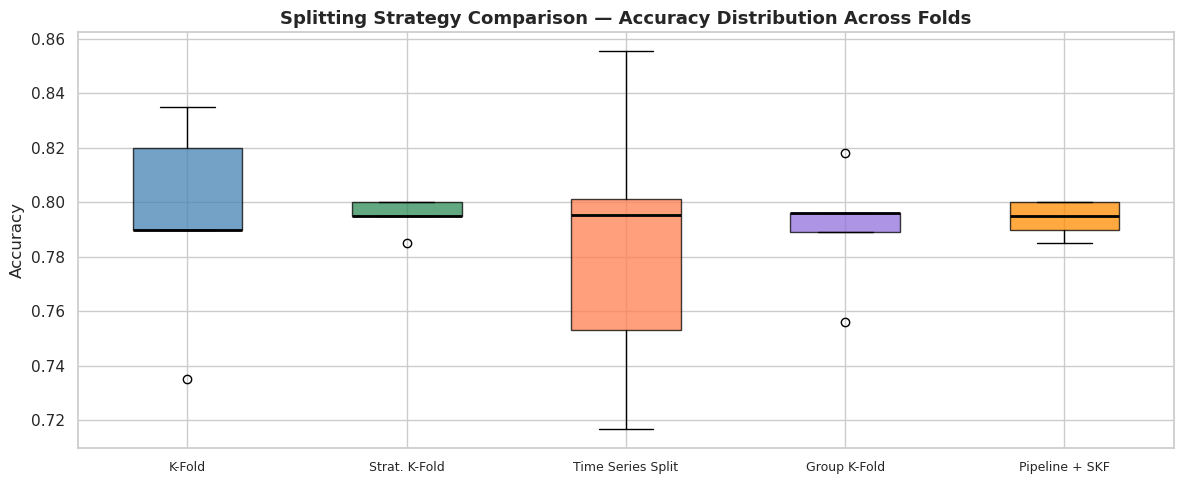

In [14]:
# ── Compare all CV strategies ─────────────────────────────────────────────
strategies = {
    'K-Fold (K=5)'          : cross_val_score(model, X, y,
                                cv=KFold(n_splits=5, shuffle=True, random_state=42),
                                scoring='accuracy'),
    'Stratified K-Fold (K=5)': cross_val_score(model, X, y,
                                cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
                                scoring='accuracy'),
    'Time Series Split (K=5)': cross_val_score(model, X, y,
                                cv=TimeSeriesSplit(n_splits=5),
                                scoring='accuracy'),
    'Group K-Fold (K=5)'    : cross_val_score(model, X, y, groups=groups,
                                cv=GroupKFold(n_splits=5),
                                scoring='accuracy'),
    'Pipeline + SKF (K=5)'  : cross_val_score(pipeline, X, y,
                                cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
                                scoring='accuracy'),
}

summary = pd.DataFrame({
    'Strategy' : list(strategies.keys()),
    'Mean Acc' : [s.mean().round(4) for s in strategies.values()],
    'Std'      : [s.std().round(4)  for s in strategies.values()],
    'Min Fold' : [s.min().round(4)  for s in strategies.values()],
    'Max Fold' : [s.max().round(4)  for s in strategies.values()],
})

print('📊 Strategy Comparison:')
print(summary.to_string(index=False))

# ── Boxplot ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
bp_data  = list(strategies.values())
bp_labels = [s.replace(' (K=5)', '').replace('Stratified ', 'Strat. ') for s in strategies.keys()]
colors   = ['steelblue', 'seagreen', 'coral', 'mediumpurple', 'darkorange']

bp = ax.boxplot(bp_data, patch_artist=True, labels=bp_labels,
                medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

ax.set_ylabel('Accuracy')
ax.set_title('Splitting Strategy Comparison — Accuracy Distribution Across Folds',
             fontsize=13, fontweight='bold')
ax.tick_params(axis='x', labelsize=9)
plt.tight_layout()
plt.show()

---
## ✅ 11. Summary & Best Practices

| Strategy | Data Used | Variance | Best For |
|----------|:---------:|:--------:|----------|
| **Random Split** | Partial | High | Large balanced datasets |
| **Stratified Split** | Partial | High | Imbalanced classification |
| **Three-Way Holdout** | Partial | High | Full dev workflow |
| **K-Fold CV** | All | Low | Small–medium datasets |
| **Stratified K-Fold** | All | Low | Imbalanced + CV |
| **Time Series Split** | Ordered | Medium | Sequential data |
| **Group K-Fold** | All | Low | Grouped data |
| **Pipeline + CV** | All | Low | Production-grade pipelines |

### 🔑 Golden Rules

1. **Split BEFORE any preprocessing** — scaling, imputation, encoding
2. **Always set `random_state`** — reproducible experiments
3. **Use `stratify=y`** for all classification tasks
4. **Never shuffle time series data** — use `TimeSeriesSplit`
5. **Use `GroupKFold`** when samples are grouped (patients, users)
6. **Use Pipelines** — they enforce leak-free preprocessing in every CV fold
7. **Touch the test set only once** — use validation set for tuning

---

## 🔗 Next Steps

- ➡️ `02_EDA/` — Explore train set only after splitting
- ➡️ `Feature_Scaling/` — Fit scaler on train, transform test
- ➡️ `05_Model_Evaluation/` — Cross-validation metrics and scoring
- ➡️ `07_Hyperparameter_Tuning/` — GridSearchCV uses CV internally